# Zombie Movie Rating Data Analysis

Zombies are one of my greatest fears, but they are incredibly varied in terms of behaviour, appearance, and lore. I was interested in identifying what characteristics caused me to be the most scared. To do this, I watched 30 zombie films and recorded information about the zombie traits, scare ratings, and environmental information. This notebook was used to produce various lists and plots to visualize data, identify biases, and observe trends relating to my fear of zombies.

<i><u>NOTE ON LANGUAGE:</u> A "rating" is a value between 1-5 or 1-10 chosen during data collection, a "score" is an algorithm assigned value of any number.</i> 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import statistics as stats
from scipy.stats import pearsonr
from collections import Counter
import random

## Organize Film Data

In [4]:
films = [] #list of dictionaries, each dictionary data from a single film

#manually adjusted weights to maximize the correlation between alg and actual rankings
zombie_traits_dict = {"Ability to speak":-1, "Can have missing body parts":6, \
                      "Can infect others":2, "Cannibalistic":3, "Cannot be killed":4, \
                      "Dark eye circles":-6, "Decaying":4, "Fast zombie":8, "Freaky eyes":2, \
                      "Fungal zombie":2, "Green skin":0, "Intelligent (but not sentient)":4, \
                      "Non-human appearance":0, "Pack behaviour":2, "Pale skin":-4,
                      "Reanimation":-1, "Rip people apart":3, "Sentience":2, "Staggery walk":1, \
                      "Voodoo/magic":-1}

earliest_release  = [2000] #value will be updated to actual earliest release
current_decade = 2020

colours = ["green", "red", "#a3a082ff", "#f2b36bff", "#3b3054ff", "#5a2b3fff", "#952631ff", "#55674cff", "#006770ff"]

exclude = ["Wendell & Wild"]
use_actual = [True] #whether manually movie rankings will be used

In [5]:
def get_films(line, earliest_release):
    '''Organizes film data from a line into a dictionary'''
    
    movie = {}

    name = line[1]
    if name in exclude: return
    movie["name"] = [name]
    
    movie["rating"] = [float(line[3])]
    movie["scariness"] = [float(line[4])]
    
    locations = line[5].split("\n- ")
    locations[0] = locations[0].strip("- ")

    movie["locations"] = locations
    movie["apocalypse"] = [True if line[6] == "Yes" else False]
    
    movie["setting_info"] = line[7].split(", ")
    
    movie["zombie_info"] = line[8].split(", ")
    if "Grey skin" in movie["zombie_info"]:
        i = movie["zombie_info"].index("Grey skin")
        movie["zombie_info"][i] = "Pale skin"
  
    movie["zombie_scary"] = [int(line[10])]
    movie["genre"] = [line[11]]
    movie["realness"] = [line[12]]

    release = int(line[13])
    if release < earliest_release[0]: 
        earliest_release[0] = release
    movie["release"] = [release]

    movie["infection_method"] = line[14].split(", ")
    
    movie["cause"] = [line[15]]

    try:
        movie["actual_rank"] = [int(line[16])]
    except:
        movie["actual_rank"] = [-1]
        use_actual[0] = False
    
    films.append(movie)

def main():
    '''Reads film data from csv and organizes into a list of film dictionaries'''
    
    with open('Zombie_response.csv', mode ='r') as file:
        csvFile = csv.reader(file)
        is_first = 1
        for lines in csvFile:
            if is_first: 
                is_first = 0
                continue
            
            get_films(lines, earliest_release)

main()

## Background Information and Context

In [7]:
def get_distribution(key, type):
    '''Creates a bar graph of the frequency of each answer for question <key>'''
    
    value_dist = {}

    for film in films:
        vals = film[key]
        for val in vals:
            if val == "": val = "None"
            if val not in value_dist.keys(): value_dist[val] = 0
            
            value_dist[val] += 1

    if "None" in value_dist.keys():
        popped = value_dist.pop("None")
        value_dist["None"] = popped
    
    fig, ax = plt.subplots(figsize=(14,5))
    if type == "pie":
        if len(value_dist) > 10:
            value_dist["Other"] = 0
            keys = list(value_dist.keys())
            for key in keys:
                if value_dist[key] <= 2:
                    value_dist.pop(key)
                    value_dist["Other"] += 1 
                    
        _, texts, _ = ax.pie(value_dist.values(), labels=value_dist.keys(), autopct='%.1f%%', pctdistance=0.85, colors=colours, textprops={'color':'white'})
        for text in texts: text.set_color('black')
    else:
        ax.bar(value_dist.keys(), value_dist.values(), color='green', edgecolor="red")
        fig.autofmt_xdate()
        ax.set_ylabel("Number of films with these labels")

def plot_rating():
    '''Plots the distribution of the film ratings'''
    
    rating_dict = {1.5:0, 1:0, 1.5:0, 2:0, 2.5:0, 3:0, 3.5:0, 4:0, 4.5:0, 5:0}

    for film in films: 
        rating_dict[film["rating"][0]] += 1

    fig8, ax8 = plt.subplots(figsize=(10,5))

    ax8.bar(rating_dict.keys(), rating_dict.values(), width=0.5, color='green', edgecolor="red")
    fig8.autofmt_xdate()
    ax8.set_xlabel("Film rating")
    ax8.set_ylabel("Number of films with these labels")

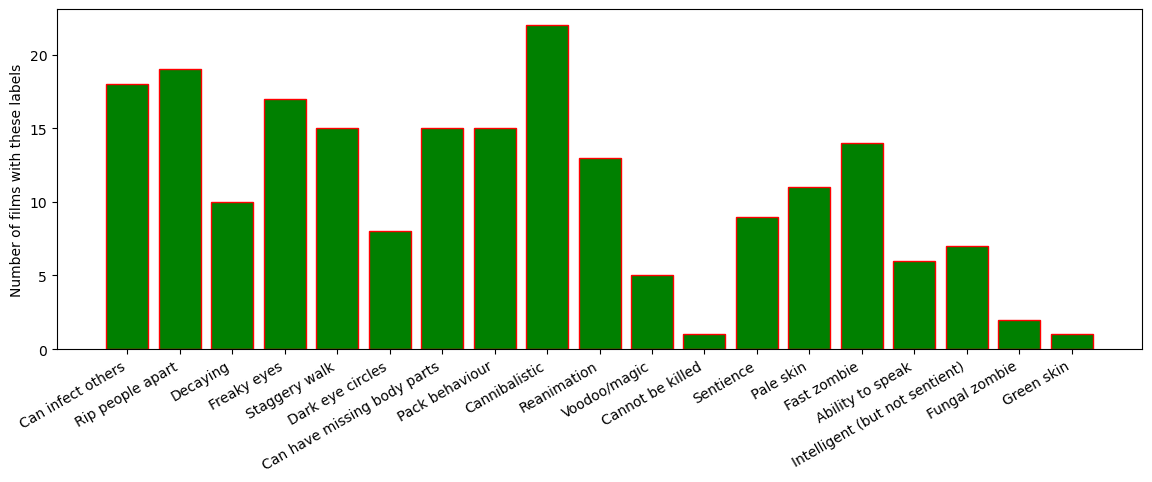

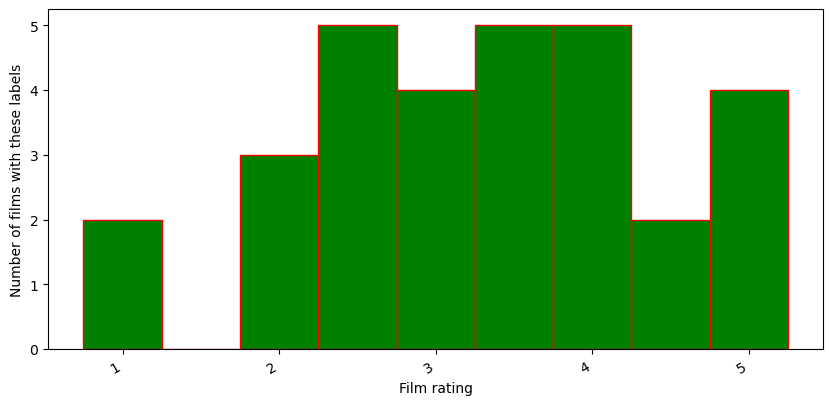

In [8]:
get_distribution("zombie_info", "bar")
plot_rating()

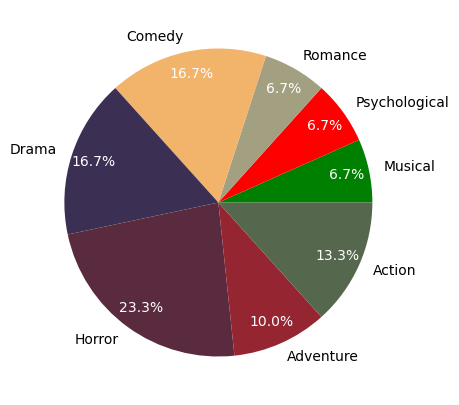

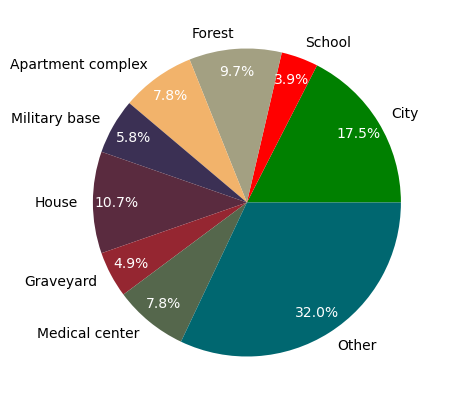

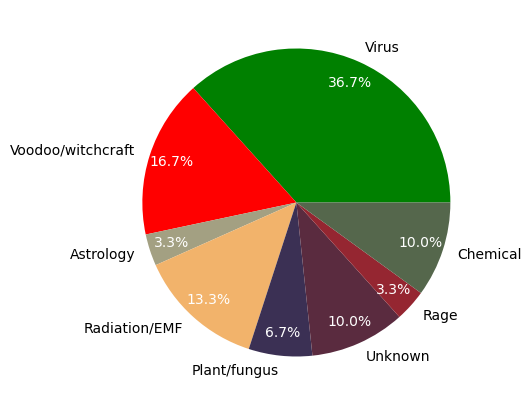

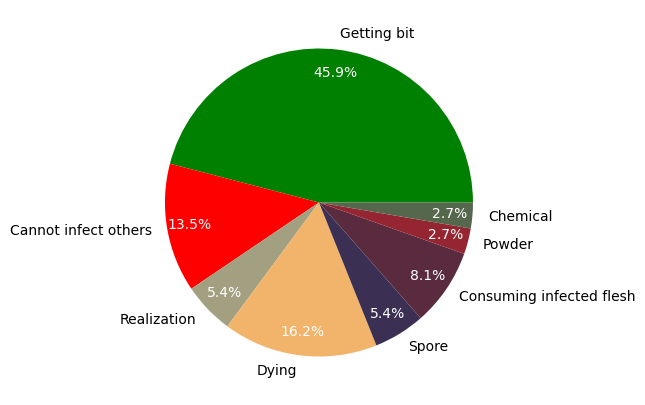

In [9]:
get_distribution("genre", "pie")
get_distribution("locations", "pie")
get_distribution("cause", "pie")
get_distribution("infection_method", "pie")

#get_distribution("realness", "pie")
#get_distribution("apocalypse", "pie")

In [10]:
def plot_scariness():
    '''Plots the movie scariness rating vs zombie scariness rating for each film'''
    
    zom_scare = []
    mov_scare = []

    fig2, ax2 = plt.subplots(figsize=(10,5))
    
    for movie in films:
        zom_scare.append(movie["zombie_scary"][0])
        mov_scare.append(movie["scariness"][0])

    c = Counter(zip(zom_scare, mov_scare))
    s = [100*c[(xx,yy)] for xx,yy in zip(zom_scare, mov_scare)]

    x = np.unique(zom_scare)
    y = np.poly1d(np.polyfit(zom_scare, mov_scare, 1))(np.unique(zom_scare))

    r, p = pearsonr(zom_scare, mov_scare)
    ax2.plot(x, y, color="red", label=f'm = {r:.3f}, p={p:.3g}')
    ax2.scatter(zom_scare, mov_scare, color="green", s=s)
    ax2.set_ylabel("Movie scariness")
    ax2.set_xlabel("Zombie scariness")
    ax2.legend()

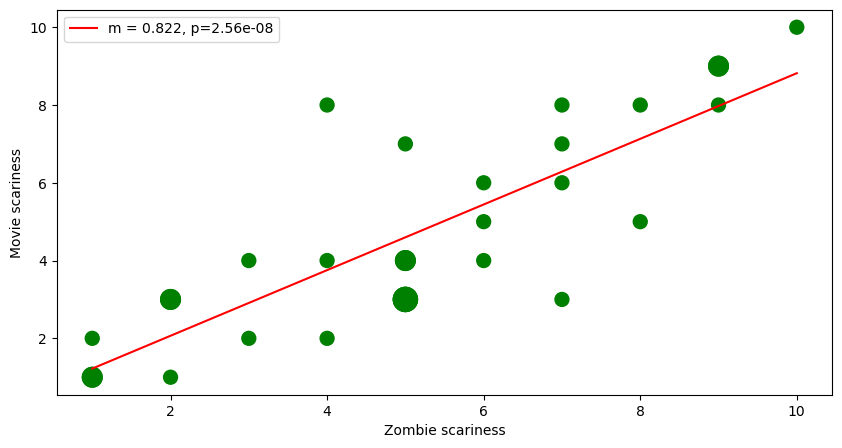

In [11]:
plot_scariness()

In [12]:
def get_release_dict():
    '''Creates a dictionary with {decade:0} pairs for each decade of zombie movies'''
    
    release_dict = {}
    for decade in range(((earliest_release[0]-10)//10)*10, current_decade+10, 10):
        release_dict[f'{decade}s'] = 0
        
    return release_dict

def plot_cause_over_time():
    '''Plots the frequency of zombism causes over the decades'''
    
    causes = {}
    num_films = get_release_dict()
    
    for film in films:
        cur_cause = film["cause"][0]
        cur_release = f'{(film["release"][0] // 10) * 10}s' #identify decade of release
        
        if cur_cause not in causes.keys():
            causes[cur_cause] = get_release_dict()
            
        causes[cur_cause][cur_release] += 1
        num_films[cur_release] += 1
    
    sorted_causes = dict(sorted(causes.items()))
    num_films_dat = np.array(list(num_films.values()))
    film_count = np.where(num_films_dat == 0, 0.000000001, num_films_dat)

    styles = ['-', '--', '-.', ':']
    #count = 1
    #fig6, ax6 = plt.subplots(figsize=(13,6))
    #ax6.set_xlabel("Decade of release")
    #ax6.set_ylabel("Number of films watched")

    fig7, ax7 = plt.subplots(figsize=(13,6))
    ax7.set_xlabel("Decade of release")
    ax7.set_ylabel("Percent of films [%]")
    
    for cause, data in sorted_causes.items():
        #ax6.scatter(data.keys(), data.values(), s=(200-(count*20)), label=f'{cause}')
        #count += 1

        counts = np.array(list(data.values())) / film_count *100
        ax7.plot(data.keys(), counts, label=f'{cause}', linestyle=random.choice(styles))

    #ax6.legend()  
    ax7.legend()    

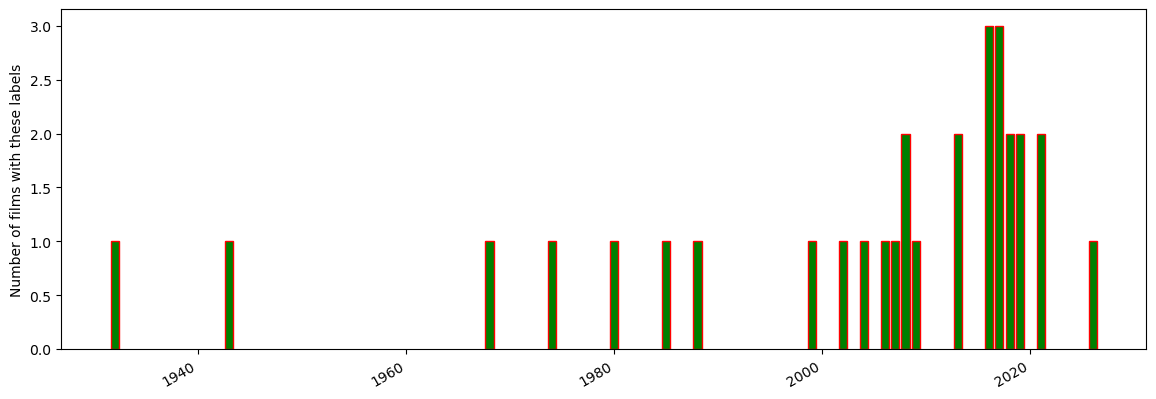

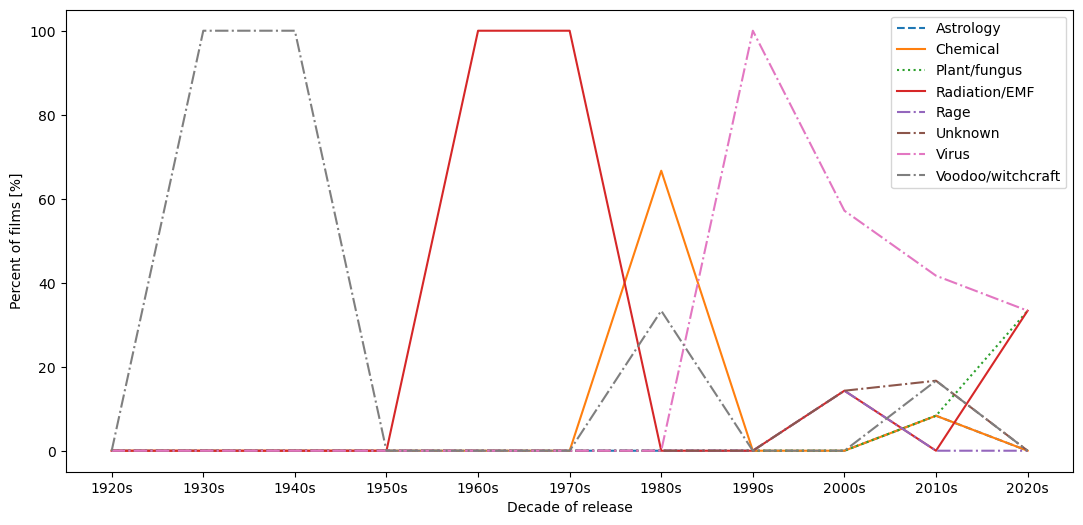

In [13]:
get_distribution("release", "bar")
plot_cause_over_time()

## Zombie Trait Rankings and Correlations

In [15]:
def print_manual_vs_scored_traits():
    '''Prints the scariest traits using the manually set trait scores'''
    
    manual_traits = {k: v for k, v in sorted(zombie_traits_dict.items(), key=lambda item: item[1])}
    manual_keys = list(manual_traits.keys())[::-1]
    
    scored_traits = score_based_alg("return")
    scored_keys = list(scored_traits.keys())[::-1]

    print('SCARIEST TRAITS RANKED: MANUAL VS SCORED\n')
    print('Ranking'+6*" "+'Manual' + 35*" " + 'Scored\n' + 100*"-")
    for i in range(len(manual_keys)):
        print_str = f'{i+1}.{10*" "}' + (' ' if i+1<10 else '')
        print_str += f'{manual_keys[i]} ({manual_traits[manual_keys[i]]})'
        print_str += (55-len(print_str))*" " 
        
        try:
            print_str += f'{scored_keys[i]} ({scored_traits[scored_keys[i]]})'
        except:
            print_str += ''
            
        print(print_str)
        
    print("\n")
    
def score_based_alg(method):
    '''Gives each movie a score corresponding to its zombie_scary rating
       Each zombie traits gets +scary for higher zombie_scary ratings and -scary for lower ones'''
    
    zombie_traits = {}
    
    for movie in films:
        score = (movie["zombie_scary"][0]-5)
        
        for trait in movie["zombie_info"]:
            if trait not in zombie_traits.keys(): zombie_traits[trait] = 0
            zombie_traits[trait] += score

    sort = {k: v for k, v in sorted(zombie_traits.items(), key=lambda item: item[1])}

    if method == "print":
        keys = list(sort.keys())[::-1]
        print('SCARIEST TRAITS RANKED BY SCORE')
        for i in range(len(keys)):
            print(f'#{i+1}: {keys[i]} ({sort[keys[i]]})')
        print("\n")
    else:
        return sort

def elim_based_alg():
    '''Identifies traits associated with scariest zombies and removes those also associated with least scary'''
    
    highest_traits = []
    lowest_traits = []
    
    for movie in films:
        if movie["zombie_scary"][0] in range(7, 11): #high range scores
            for trait in movie["zombie_info"]:
                if trait not in highest_traits: highest_traits.append(trait)
        elif movie["zombie_scary"][0] in range(1, 4): #low range scores
            for trait in movie["zombie_info"]:
                if trait not in lowest_traits: lowest_traits.append(trait)

    count = 0
    print("LIST OF SCARIEST TRAITS USING ELIMINATION METHOD")
    for trait in highest_traits:
        if trait in lowest_traits:
            i = highest_traits.index(trait)
            highest_traits.pop(i)
        else:
            count += 1
            print(f'{count}) {trait}')
    print("\n")

In [16]:
def perof_x_also_y(x_key, x, y_key, y):
    '''Gives the percentage of films with x trait that also have y trait'''
    
    count_x = 0
    count_x_and_y = 0

    for film in films:
        test_x = film[x_key]
        if x in test_x:
            count_x += 1
            test_y = film[y_key]
            if y in test_y: count_x_and_y += 1

    percent = count_x_and_y/count_x
    print(f'Percent of films with ({x_key}={x}) that have ({y_key}={y}): {percent *100 :.2f}%\n')

def get_pearson_coef(trait):
    '''Determines the pearson correlation coefficient and p-value of a zombie trait and the 
       scariness ratings of zombies (whether that trait is associated with scarier zombies)'''
    
    x_data = []
    y_data = []

    for film in films:
        x_data.append(int(trait in film["zombie_info"]))
        y_data.append(film["zombie_scary"][0]/10)

    if np.std(x_data, ddof=1) == 0: return None

    r, p = pearsonr(x_data, y_data)
    return r, p

def get_correlated():
    '''Finds the zombie traits that have a positive correlation with scariness scores'''
    
    print("TRAITS 'CORRELATED' WITH ZOMBIE SCARINESS")
    count = 0
    for trait in zombie_traits_dict.keys():
        result = get_pearson_coef(trait)
        if result is None: continue
        
        r, p = result
        if r > 0:
            count += 1
            print_str = f"{count}) {trait} (r={r:.3f}, p={p:.3g})"
            if p >= 0.05: print_str += (70-len(print_str))*" " + "NOT SIGNFICANT"
            print(print_str)
            
    print("\n")  

def get_correlation(film_field_1, film_field_2):
    '''Finds the correlation between two fields and prints the correlation and significance'''
    
    x_data = []
    y_data = []

    for film in films:
        x_data.append(film[film_field_1][0])
        y_data.append(film[film_field_2][0])

    #if np.std(x_data, ddof=1) == 0: return None
    r, p = pearsonr(x_data, y_data)

    if r >= 0.1:     print_str = "Positive "
    elif r <= -0.1:  print_str = "Negative "
    else:            print_str = "No "
        
    print_str += f"correlation between: {film_field_1}, {film_field_2} (r={r:.3f}, p={p:.3g})"
    if p >= 0.05: print_str += (90-len(print_str))*" " + "NOT SIGNFICANT"
    print(print_str)

In [17]:
#elim_based_alg()
score_based_alg("print")
print_manual_vs_scored_traits()
get_correlated()

print("DATA CORRELATIONS")
get_correlation("apocalypse", "zombie_scary")  #whether apocalypse, scariness of zombies
get_correlation("apocalypse", "scariness")     #whether apocalypse, scariness of movie
get_correlation("zombie_scary", "scariness")   #scariness of zombies, scariness of movie
get_correlation("release", "zombie_scary")    #year of release, zombie scariness
print("\n")

#perof_x_also_y("setting_info", "Virus being spread", "zombie_info", "Rip people apart")

SCARIEST TRAITS RANKED BY SCORE
#1: Can infect others (27)
#2: Fast zombie (23)
#3: Pack behaviour (18)
#4: Can have missing body parts (13)
#5: Rip people apart (12)
#6: Cannibalistic (11)
#7: Decaying (8)
#8: Intelligent (but not sentient) (7)
#9: Freaky eyes (7)
#10: Fungal zombie (4)
#11: Cannot be killed (-1)
#12: Green skin (-2)
#13: Ability to speak (-4)
#14: Sentience (-8)
#15: Reanimation (-10)
#16: Dark eye circles (-10)
#17: Voodoo/magic (-11)
#18: Pale skin (-13)
#19: Staggery walk (-13)


SCARIEST TRAITS RANKED: MANUAL VS SCORED

Ranking      Manual                                   Scored
----------------------------------------------------------------------------------------------------
1.           Fast zombie (8)                           Can infect others (27)
2.           Can have missing body parts (6)           Fast zombie (23)
3.           Intelligent (but not sentient) (4)        Pack behaviour (18)
4.           Decaying (4)                              Can have 

## Film Rankings

In [19]:
def actual_scariest_zoms(method):
    '''Ranks zombies by scariest using their actual ratings'''
    
    zom_rating_dict = {}
    
    if use_actual[0]:                     #rank based on manually input rankings
        film_property = "actual_rank" 
        order = 1
    else:                                 #rank based on highest zombie ratings
        film_property = "zombie_scary"    #(may have arbitrary ordering)
        order = -1

    for film in films:
        zom_rating_dict[film["name"][0]] = film[film_property][0]

    sort = {k: v for k, v in sorted(zom_rating_dict.items(), key=lambda item: item[1])}
    keys = list(sort.keys())[::order]

    if method == "print":
        print('ACTUAL RANKING OF MOVIES WITH SCARIEST ZOMBIES')
        for i in range(len(keys)):
            str = f'#{i+1}: {keys[i]}'
            if not order: str += f' ({sort[keys[i]]})'
            print(str)
        print("\n")
    else:
        return sort

def get_scariest_zoms(method, is_manual):
    '''Gets a list of the films with the scariest zombies by scoring them (adding the 
       score determined in the scoring alg for each trait the zombies have)'''
    
    film_scary_scores = {}

    if is_manual: 
        scariest_features = zombie_traits_dict
        add_str = "MANUAL "
    else:
        scariest_features = score_based_alg("return")
        add_str = ""
        
    for film in films:
        cur_score = 0
        for zom_trait in film["zombie_info"]:
            cur_score += scariest_features[zom_trait]
    
        film_scary_scores[film["name"][0]] = cur_score
    
    sort = {k: v for k, v in sorted(film_scary_scores.items(), key=lambda item: item[1])}
    keys = list(sort.keys())[::-1]

    if method == "print":
        print('RANKING OF MOVIES WITH SCARIEST ZOMBIES USING ' + add_str + 'SCORING METHOD')
        for i in range(len(keys)):
            print(f'#{i+1}: {keys[i]} ({sort[keys[i]]})')
        print("\n")
    else:
        return sort
    

In [20]:
actual_scariest_zoms("print")
get_scariest_zoms("print", False)
get_scariest_zoms("print", True)

ACTUAL RANKING OF MOVIES WITH SCARIEST ZOMBIES
#1: The Sadness
#2: World War Z
#3: Train to Busan
#4: [Rec]
#5: Blood Quantum
#6: Zombieland
#7: The Cured
#8: The Girl With All the Gifts
#9: The Spore
#10: The Night Eats the World
#11: City of the Living Dead
#12: 28 Days Later
#13: Anna and the Apocalypse
#14: Pontypool
#15: Shaun of the Dead
#16: We Bury the Dead
#17: Night of the Living Dead
#18: Colin
#19: I, Zombie
#20: The Autopsy of Jane Doe
#21: The Dead Don't Die
#22: Re-Animator
#23: Fido
#24: Let Sleeping Corpses Lie
#25: Warm Bodies
#26: One Cut of the Dead
#27: The Serpent and the Rainbow
#28: Z-O-M-B-I-E-S
#29: White Zombie
#30: I Walked With a Zombie


RANKING OF MOVIES WITH SCARIEST ZOMBIES USING SCORING METHOD
#1: Zombieland (126)
#2: The Girl With All the Gifts (103)
#3: Blood Quantum (101)
#4: The Night Eats the World (94)
#5: World War Z (88)
#6: Pontypool (87)
#7: Train to Busan (86)
#8: The Sadness (86)
#9: The Cured (77)
#10: [Rec] (73)
#11: Anna and the Apocalyp

In [21]:
def plot_diff_zom_scariness(is_manual):
    '''Creates different plots showing difference between scoring algorithm ranking and actual ranking'''

    if use_actual[0]: order = 1
    else:             order = -1
    
    scored_zoms_ordered = list(get_scariest_zoms("return", is_manual).keys())[::-1]
    rated_zoms_ordered = list(actual_scariest_zoms("return").keys())[::order]

    movie_names = []
    scoring = []
    rating = []
    
    for movie_name in scored_zoms_ordered:
        scoring.append( scored_zoms_ordered.index(movie_name)+1 ) 
        rating.append( rated_zoms_ordered.index(movie_name)+1 )
        movie_names.append(movie_name)
    
    #scatter plot showing the two rankings for each film
    fig3, ax3 = plt.subplots(figsize=(12,8))
    ax3.scatter(movie_names, rating, color="red", s=100, label="Actual ranking")
    ax3.scatter(movie_names, scoring, color="green", s=50, label="Algorithm ranking")
    ax3.set_yticks(np.arange(1, len(scoring), 1.0))
    ax3.set_ylabel("Ranking")
    ax3.set_xlabel("Movie name")
    ax3.legend(loc='upper left')
    fig3.autofmt_xdate()

    #bar plot showing differences between rankings
    diff = np.array(rating) - np.array(scoring)
    rate_diff = [0.04 if x == 0 else x for x in diff]
    fig4, ax4 = plt.subplots(figsize=(12,8))
    ax4.bar(movie_names, rate_diff, color=['green' if v >= 0 else 'red' for v in rate_diff])
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel("Difference in ranking (Actual - Algorithm)")
    ax4.set_xlabel("Film name")
    ax4.set_yticks(np.arange(-8, max(rate_diff)+1, 1.0))
    fig4.autofmt_xdate()

    #scatter plot showing each movie as (actual rank, algo rank) point, as best fit
    fig5, ax5 = plt.subplots(figsize=(12,8))
    ax5.scatter(rating, scoring, color="green", s=100)
    ax5.set_xlabel("Actual ranking")
    ax5.set_ylabel("Algorithm ranking")
    
    x = np.unique(rating)
    y = np.poly1d(np.polyfit(rating, scoring, 1))(np.unique(rating))
    r, p = pearsonr(rating, scoring)
    ax5.plot(x, y, color="red", label=f'm = {r:.3f}, p={p:.3g}')
    ax5.legend(loc='upper left')
    ax5.set_xticks(np.arange(1, len(rating), 1.0))
    ax5.set_yticks(np.arange(1, len(scoring), 1.0))

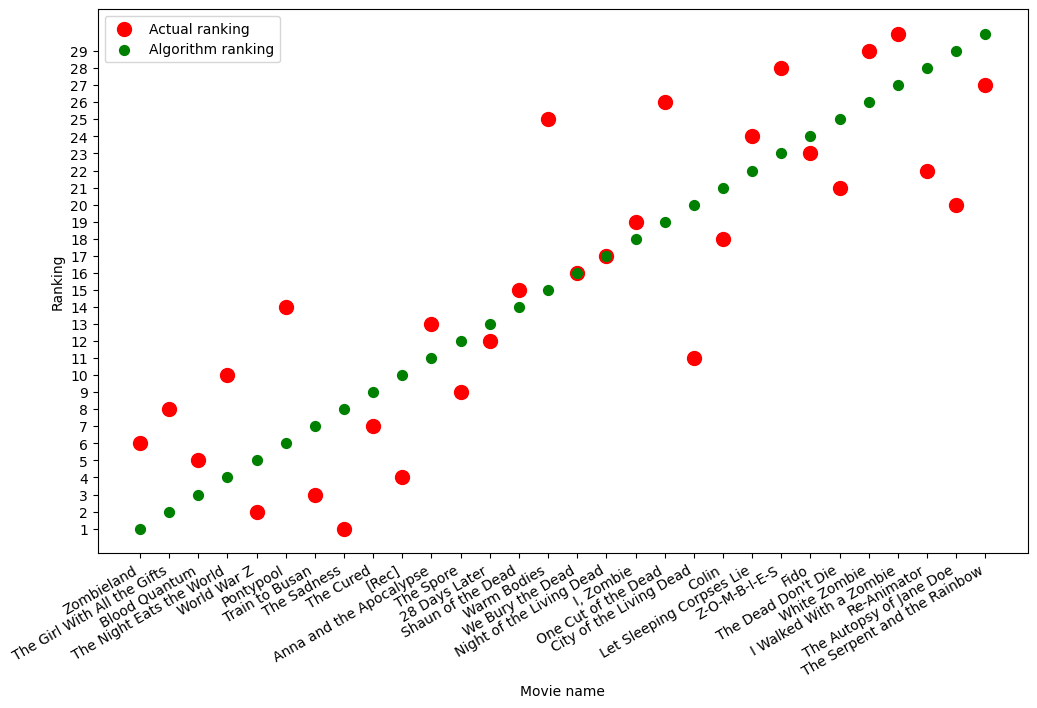

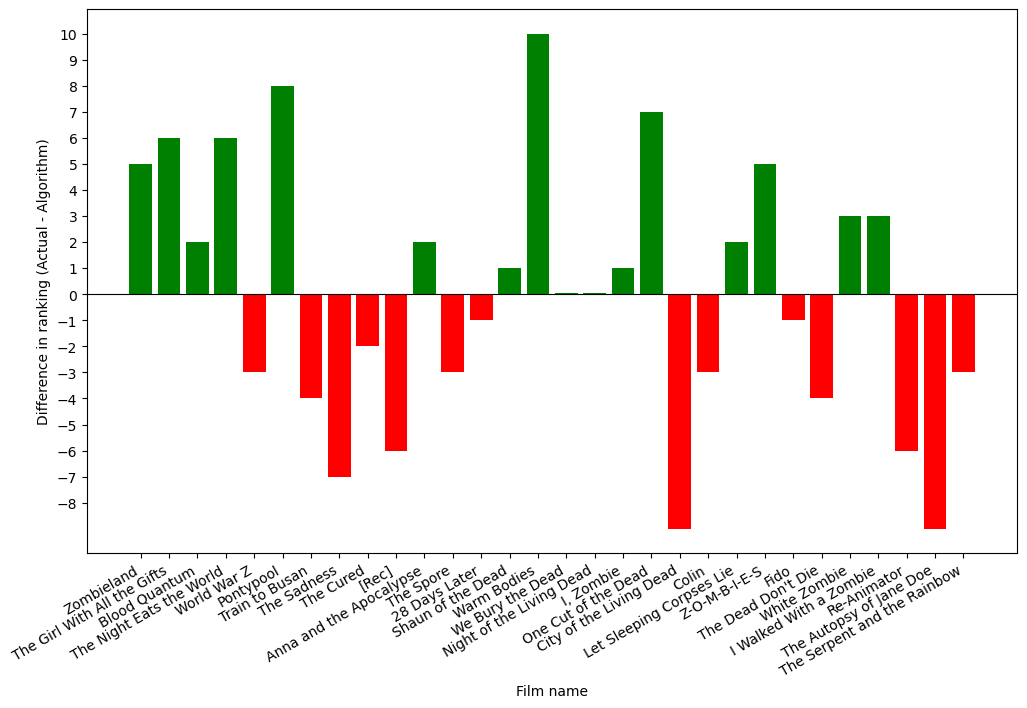

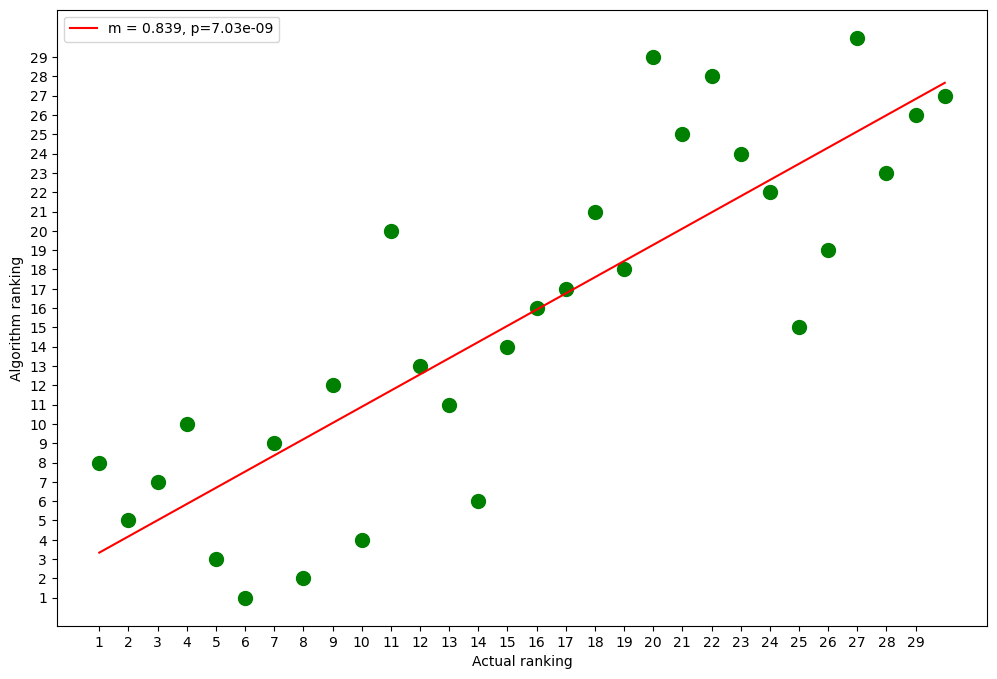

In [22]:
plot_diff_zom_scariness(False) #utilizes scoring alg rankings

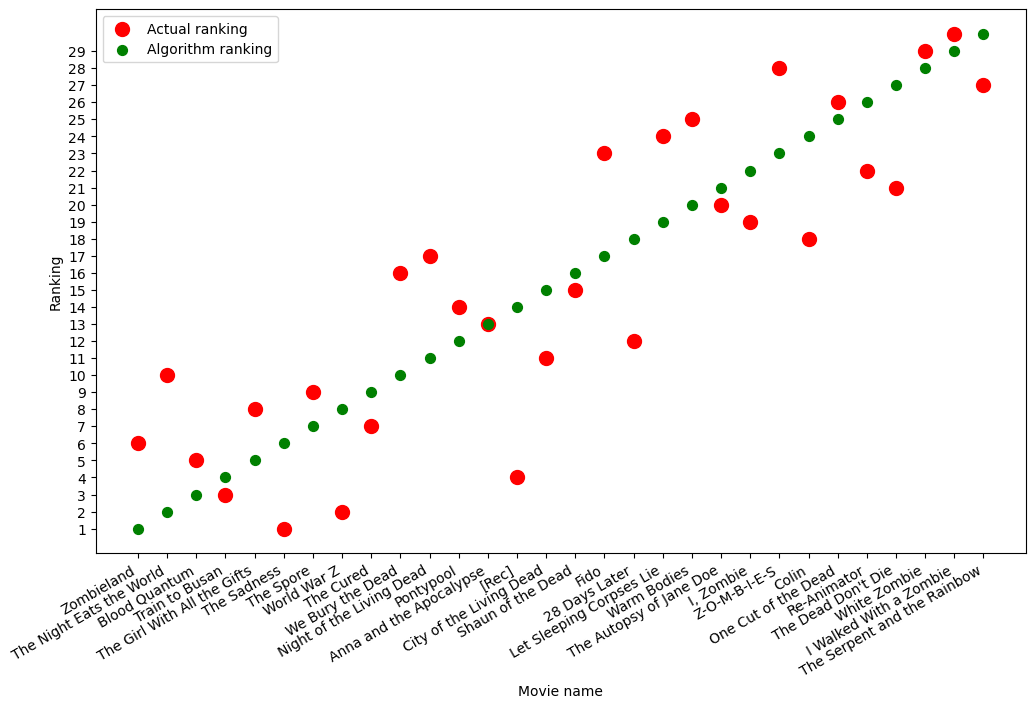

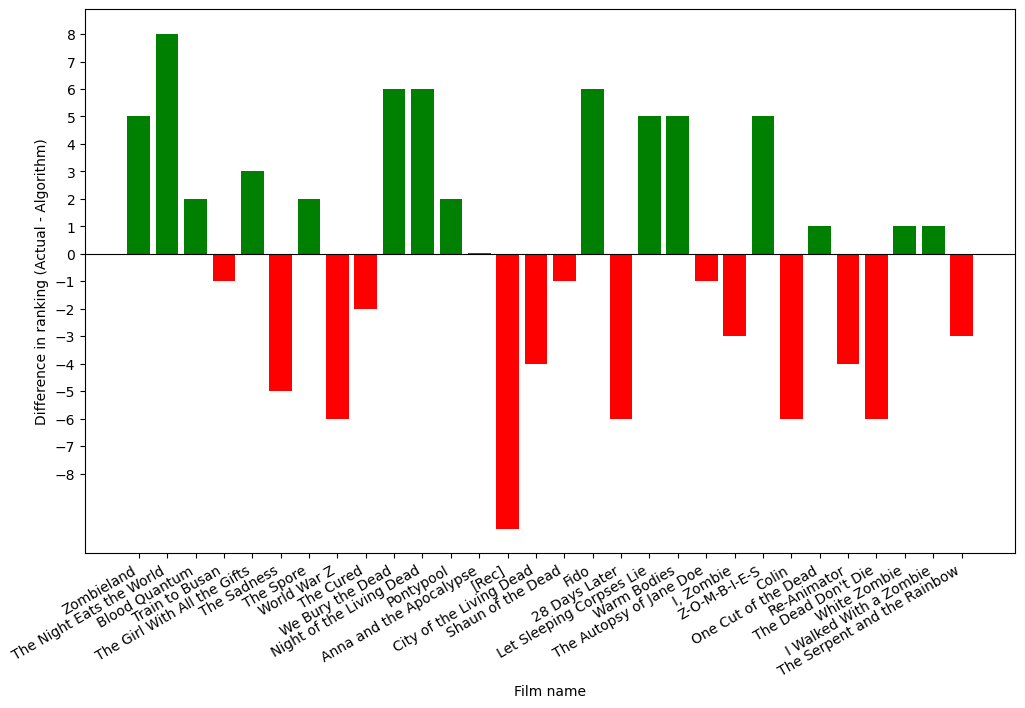

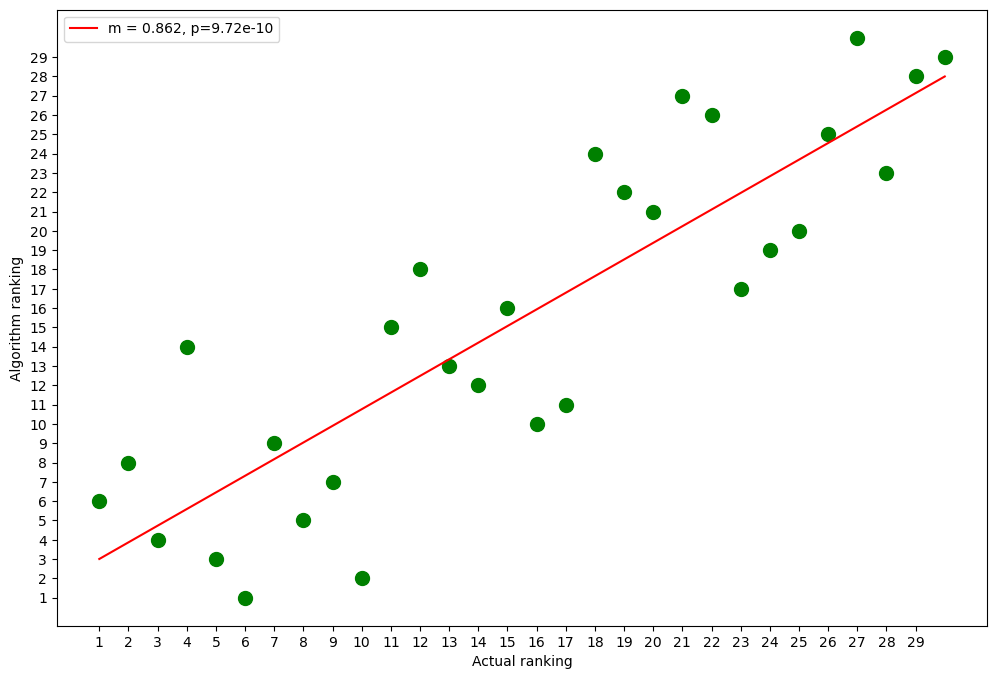

In [23]:
plot_diff_zom_scariness(True) #utilizes manual scoring rankings